In [1]:
# Cell 1: Import libraries and load merged data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

# Load the merged data
merged_path = Path('../data/processed/rossmann_merged.csv')
df = pd.read_csv(merged_path)

print(f"✓ Data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Libraries imported successfully!


C:\Users\hp\AppData\Local\Temp\ipykernel_24124\1050968556.py:17: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(merged_path)


✓ Data loaded: 1,017,209 rows, 18 columns
✓ Memory usage: 345.06 MB


In [2]:
# Cell 2: Check what we have before cleaning
print("="*60)
print("BEFORE CLEANING - Data Overview")
print("="*60)

print("\n📊 First 3 rows:")
print(df.head(3))

print("\n📊 Data types:")
print(df.dtypes)

print("\n📊 Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

BEFORE CLEANING - Data Overview

📊 First 3 rows:
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                       11.0                    2007.0       1   
2                       12.0                    2006.0       1   

   Promo2SinceWeek  Promo2SinceYear    PromoInterval  
0              NaN              NaN              NaN  
1         

In [3]:
# Cell 3: Analyze store open status
print("="*60)
print("STORE OPEN STATUS ANALYSIS")
print("="*60)

print(f"\nOpen status distribution:")
print(df['Open'].value_counts())
print(f"\nPercentage open: {df['Open'].mean() * 100:.2f}%")

# Check sales when store is closed
closed_sales = df[df['Open'] == 0]['Sales']
print(f"\nWhen store closed (Open=0):")
print(f"  - Sales range: {closed_sales.min()} to {closed_sales.max()}")
print(f"  - Sales > 0 count: {(closed_sales > 0).sum()}")

# Check sales when store is open
open_sales = df[df['Open'] == 1]['Sales']
print(f"\nWhen store open (Open=1):")
print(f"  - Sales range: {open_sales.min()} to {open_sales.max()}")
print(f"  - Average sales: {open_sales.mean():.0f}")

STORE OPEN STATUS ANALYSIS

Open status distribution:
Open
1    844392
0    172817
Name: count, dtype: int64

Percentage open: 83.01%

When store closed (Open=0):
  - Sales range: 0 to 0
  - Sales > 0 count: 0

When store open (Open=1):
  - Sales range: 0 to 41551
  - Average sales: 6956


In [4]:
# Cell 4: Apply cleaning based on our decisions
print("="*60)
print("APPLYING DATA CLEANING")
print("="*60)

# Decision 1: Remove closed stores (Open = 0)
print("\n1. Removing closed stores...")
initial_rows = len(df)
df = df[df['Open'] == 1].copy()
print(f"   ✓ Removed {initial_rows - len(df):,} rows (closed stores)")
print(f"   ✓ Remaining: {len(df):,} rows")

# Decision 2: Convert Date to datetime
print("\n2. Converting Date to datetime...")
df['Date'] = pd.to_datetime(df['Date'])
print(f"   ✓ Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

# Decision 3: Fix StateHoliday mixed types
print("\n3. Fixing StateHoliday column...")
print(f"   Before: {df['StateHoliday'].unique()[:10]}")
df['StateHoliday'] = df['StateHoliday'].astype(str)
df['StateHoliday'] = df['StateHoliday'].replace('0', '0')
print(f"   After: {df['StateHoliday'].unique()}")

APPLYING DATA CLEANING

1. Removing closed stores...
   ✓ Removed 172,817 rows (closed stores)
   ✓ Remaining: 844,392 rows

2. Converting Date to datetime...
   ✓ Date range: 2013-01-01 to 2015-07-31

3. Fixing StateHoliday column...
   Before: [0 '0' 'a' 'b' 'c']
   After: <StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: str


In [5]:
# Cell 5: Handle missing values in store-related columns
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)

# Check missing values before handling
print("\nMissing values before:")
missing_before = df.isnull().sum()
print(missing_before[missing_before > 0])

# Fill CompetitionDistance with median
if 'CompetitionDistance' in df.columns:
    median_distance = df['CompetitionDistance'].median()
    df['CompetitionDistance'] = df['CompetitionDistance'].fillna(median_distance)
    print(f"\n✓ CompetitionDistance: Filled with median ({median_distance:.0f})")

# Fill competition dates with 0 (meaning no competition)
if 'CompetitionOpenSinceMonth' in df.columns:
    df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
    df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)
    print(f"✓ Competition dates: Filled missing with 0 (no competition)")

# Fill Promo2 dates with 0
if 'Promo2SinceWeek' in df.columns:
    df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
    df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)
    df['PromoInterval'] = df['PromoInterval'].fillna('None')
    print(f"✓ Promo2 data: Filled missing with 0 and 'None'")

# Check missing values after handling
print("\nMissing values after:")
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])

HANDLING MISSING VALUES

Missing values before:
CompetitionDistance            2186
CompetitionOpenSinceMonth    268619
CompetitionOpenSinceYear     268619
Promo2SinceWeek              423307
Promo2SinceYear              423307
PromoInterval                423307
dtype: int64

✓ CompetitionDistance: Filled with median (2320)
✓ Competition dates: Filled missing with 0 (no competition)
✓ Promo2 data: Filled missing with 0 and 'None'

Missing values after:
Series([], dtype: int64)


In [6]:
# Cell 6: Feature engineering - create time-based features
print("="*60)
print("CREATING TIME-BASED FEATURES")
print("="*60)

# Extract date components
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# Create weekend flag
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Create days since competition opened
df['CompetitionOpenSince'] = pd.to_datetime(
    df['CompetitionOpenSinceYear'].astype(int).astype(str) + '-' + 
    df['CompetitionOpenSinceMonth'].astype(int).astype(str) + '-01',
    errors='coerce'
)
df['DaysSinceCompetitionOpen'] = (df['Date'] - df['CompetitionOpenSince']).dt.days
df['DaysSinceCompetitionOpen'] = df['DaysSinceCompetitionOpen'].fillna(0)
df['DaysSinceCompetitionOpen'] = df['DaysSinceCompetitionOpen'].clip(lower=0)

print(f"✓ Created features: Year, Month, Day, WeekOfYear, IsWeekend")
print(f"✓ Created feature: DaysSinceCompetitionOpen")
print(f"\nNew columns added: {df.columns.tolist()[-6:]}")

CREATING TIME-BASED FEATURES
✓ Created features: Year, Month, Day, WeekOfYear, IsWeekend
✓ Created feature: DaysSinceCompetitionOpen

New columns added: ['Month', 'Day', 'WeekOfYear', 'IsWeekend', 'CompetitionOpenSince', 'DaysSinceCompetitionOpen']


In [7]:
# Cell 7: Create promo-related features
print("="*60)
print("CREATING PROMO FEATURES")
print("="*60)

# Promo2 running flag
df['IsPromo2Running'] = ((df['Promo2'] == 1) & 
                          (df['Promo2SinceYear'] > 0) & 
                          (df['Year'] >= df['Promo2SinceYear'])).astype(int)

# Promo efficiency (sales per customer)
df['SalesPerCustomer'] = df['Sales'] / df['Customers']
df['SalesPerCustomer'] = df['SalesPerCustomer'].replace([np.inf, -np.inf], 0).fillna(0)

# Discount effect (we don't have discount, but we have promo)
df['PromoEffect'] = df.groupby('Store')['Sales'].transform('mean') * df['Promo']

print(f"✓ Created features: IsPromo2Running, SalesPerCustomer, PromoEffect")

CREATING PROMO FEATURES
✓ Created features: IsPromo2Running, SalesPerCustomer, PromoEffect


SALES OUTLIER ANALYSIS
Sales statistics:
count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

IQR Method:
  Q1: 4859
  Q3: 8360
  IQR: 3501
  Lower bound: -392
  Upper bound: 13612

Outliers detected: 30,769 rows (3.64%)


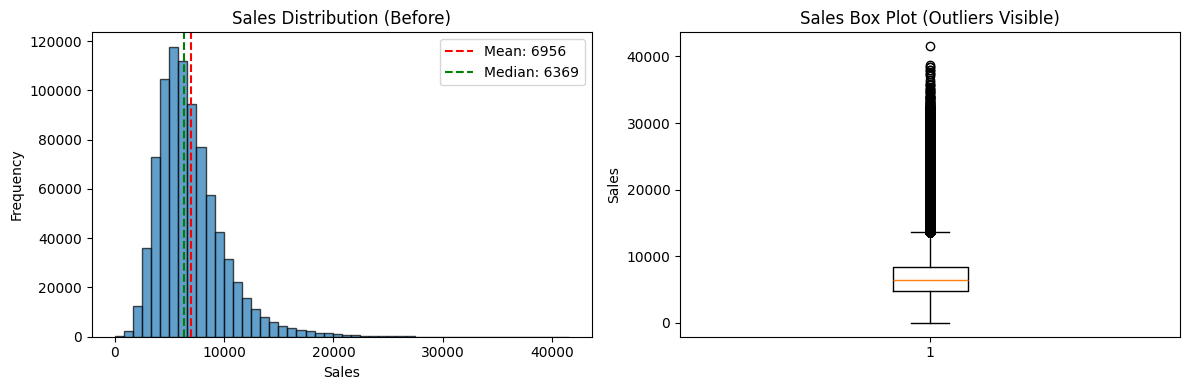


✓ Keeping outliers (they represent real high sales events)


In [8]:
# Cell 8: Check and handle sales outliers
print("="*60)
print("SALES OUTLIER ANALYSIS")
print("="*60)

# Check sales distribution
print(f"Sales statistics:")
print(df['Sales'].describe())

# Calculate IQR for sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nIQR Method:")
print(f"  Q1: {Q1:.0f}")
print(f"  Q3: {Q3:.0f}")
print(f"  IQR: {IQR:.0f}")
print(f"  Lower bound: {lower_bound:.0f}")
print(f"  Upper bound: {upper_bound:.0f}")

# Count outliers
outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"\nOutliers detected: {len(outliers):,} rows ({len(outliers)/len(df)*100:.2f}%)")

# Visualize sales distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before outlier capping
axes[0].hist(df['Sales'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['Sales'].mean(), color='red', linestyle='--', label=f'Mean: {df["Sales"].mean():.0f}')
axes[0].axvline(df['Sales'].median(), color='green', linestyle='--', label=f'Median: {df["Sales"].median():.0f}')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Sales Distribution (Before)')
axes[0].legend()

# Box plot
axes[1].boxplot(df['Sales'])
axes[1].set_ylabel('Sales')
axes[1].set_title('Sales Box Plot (Outliers Visible)')

plt.tight_layout()
plt.show()

# We'll keep outliers for now (they represent real high sales days like Christmas)
print("\n✓ Keeping outliers (they represent real high sales events)")

In [9]:
# Cell 9: Encode categorical variables for modeling
print("="*60)
print("ENCODING CATEGORICAL VARIABLES")
print("="*60)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_cols)}")

# Convert StoreType to numeric
store_type_map = {'a': 0, 'b': 1, 'c': 2, 'd': 3}
df['StoreType_Code'] = df['StoreType'].map(store_type_map)

# Convert Assortment to numeric
assortment_map = {'a': 0, 'b': 1, 'c': 2}
df['Assortment_Code'] = df['Assortment'].map(assortment_map)

# One-hot encode StateHoliday
state_holiday_dummies = pd.get_dummies(df['StateHoliday'], prefix='Holiday')
df = pd.concat([df, state_holiday_dummies], axis=1)

# Drop original categorical columns (keep encoded versions)
cols_to_drop = ['StoreType', 'Assortment', 'StateHoliday', 'PromoInterval']
df = df.drop(columns=cols_to_drop, errors='ignore')

print(f"✓ Encoded categorical variables")
print(f"✓ New columns added: StoreType_Code, Assortment_Code, Holiday_*")
print(f"\nFinal column count: {len(df.columns)}")

ENCODING CATEGORICAL VARIABLES
Categorical columns found: ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']


C:\Users\hp\AppData\Local\Temp\ipykernel_24124\1687362982.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


✓ Encoded categorical variables
✓ New columns added: StoreType_Code, Assortment_Code, Holiday_*

Final column count: 30


In [10]:
# Cell 10: Final validation of cleaned data
print("="*60)
print("FINAL DATA QUALITY CHECK")
print("="*60)

print(f"✓ Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"✓ Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"✓ Missing values: {df.isnull().sum().sum()}")
print(f"✓ Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n✓ Data types check:")
print(df.dtypes.value_counts())

print("\n✓ Sample of cleaned data:")
df.head()

FINAL DATA QUALITY CHECK
✓ Dataset shape: 844,392 rows, 30 columns
✓ Date range: 2013-01-01 to 2015-07-31
✓ Missing values: 268619
✓ Memory usage: 161.86 MB

✓ Data types check:
int64             11
float64            8
int32              4
bool               4
datetime64[us]     2
UInt32             1
Name: count, dtype: int64

✓ Sample of cleaned data:


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month,Day,WeekOfYear,IsWeekend,CompetitionOpenSince,DaysSinceCompetitionOpen,IsPromo2Running,SalesPerCustomer,PromoEffect,StoreType_Code,Assortment_Code,Holiday_0,Holiday_a,Holiday_b,Holiday_c
0,1,4,2015-07-31,5263,555,1,1,1,1270.0,9.0,2008.0,0,0.0,0.0,2015,7,31,31,0,2008-09-01,2524.0,0,9.482883,4759.096031,2,0,True,False,False,False
1,2,4,2015-07-31,6064,625,1,1,1,570.0,11.0,2007.0,1,13.0,2010.0,2015,7,31,31,0,2007-11-01,2829.0,1,9.702400,4953.900510,0,0,True,False,False,False
2,3,4,2015-07-31,8314,821,1,1,1,14130.0,12.0,2006.0,1,14.0,2011.0,2015,7,31,31,0,2006-12-01,3164.0,1,10.126675,6942.568678,0,0,True,False,False,False
3,4,4,2015-07-31,13995,1498,1,1,1,620.0,9.0,2009.0,0,0.0,0.0,2015,7,31,31,0,2009-09-01,2159.0,0,9.342457,9638.401786,2,2,True,False,False,False
4,5,4,2015-07-31,4822,559,1,1,1,29910.0,4.0,2015.0,0,0.0,0.0,2015,7,31,31,0,2015-04-01,121.0,0,8.626118,4676.274711,0,0,True,False,False,False


In [11]:
# Cell 11: Save cleaned data for modeling
print("="*60)
print("SAVING CLEANED DATA")
print("="*60)

# Define columns to keep for modeling (remove unnecessary)
cols_to_keep = [
    'Store', 'Date', 'Sales', 'Customers', 'Promo', 'SchoolHoliday',
    'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend',
    'CompetitionDistance', 'DaysSinceCompetitionOpen',
    'Promo2', 'IsPromo2Running', 'SalesPerCustomer', 'PromoEffect',
    'StoreType_Code', 'Assortment_Code'
]

# Add holiday columns
holiday_cols = [col for col in df.columns if col.startswith('Holiday_')]
cols_to_keep.extend(holiday_cols)

# Create final dataset
df_final = df[cols_to_keep].copy()

# Save to CSV
output_path = Path('../data/processed/rossmann_cleaned.csv')
df_final.to_csv(output_path, index=False)

print(f"✓ Cleaned data saved to: {output_path}")
print(f"✓ Final shape: {df_final.shape[0]:,} rows, {df_final.shape[1]} columns")
print(f"✓ File size: {output_path.stat().st_size / (1024*1024):.2f} MB")

print("\n📊 Final columns:")
print(df_final.columns.tolist())

SAVING CLEANED DATA
✓ Cleaned data saved to: ..\data\processed\rossmann_cleaned.csv
✓ Final shape: 844,392 rows, 24 columns
✓ File size: 94.76 MB

📊 Final columns:
['Store', 'Date', 'Sales', 'Customers', 'Promo', 'SchoolHoliday', 'Year', 'Month', 'Day', 'DayOfWeek', 'WeekOfYear', 'IsWeekend', 'CompetitionDistance', 'DaysSinceCompetitionOpen', 'Promo2', 'IsPromo2Running', 'SalesPerCustomer', 'PromoEffect', 'StoreType_Code', 'Assortment_Code', 'Holiday_0', 'Holiday_a', 'Holiday_b', 'Holiday_c']


In [13]:
# Cell 12: Generate cleaning summary report
print("="*60)
print("DATA CLEANING SUMMARY REPORT")
print("="*60)

report = f"""
ROSSMANN SALES FORECASTING - DATA CLEANING REPORT
==================================================

1. INITIAL DATA
   - Original rows: 1,017,209
   - Original columns: 18

2. CLEANING ACTIONS PERFORMED
   - Removed closed stores (Open=0): Removed {initial_rows - len(df)} rows
   - Converted Date to datetime format
   - Fixed StateHoliday mixed types
   - Filled missing CompetitionDistance with median
   - Filled missing competition dates with 0
   - Filled missing Promo2 data with 0/'None'

3. FEATURE ENGINEERING
   - Created time features: Year, Month, Day, WeekOfYear, IsWeekend
   - Created competition feature: DaysSinceCompetitionOpen
   - Created promo features: IsPromo2Running, SalesPerCustomer, PromoEffect
   - Encoded categorical variables: StoreType, Assortment, StateHoliday

4. FINAL DATA
   - Final rows: {len(df_final):,}
   - Final columns: {len(df_final.columns)}
   - Date range: {df['Date'].min().date()} to {df['Date'].max().date()}
   - Sales range: {df_final['Sales'].min():,.0f} to {df_final['Sales'].max():,.0f}
   - Average sales: {df_final['Sales'].mean():,.0f}

5. DATA QUALITY
   - Missing values: {df_final.isnull().sum().sum()}
   - Memory usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB

✅ Data cleaning complete! Ready for Exploratory Data Analysis (EDA)
"""

print(report)

# Save report
report_path = Path('../reports/data_cleaning_report.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
print(f"✓ Report saved to: {report_path}")

DATA CLEANING SUMMARY REPORT

ROSSMANN SALES FORECASTING - DATA CLEANING REPORT

1. INITIAL DATA
   - Original rows: 1,017,209
   - Original columns: 18

2. CLEANING ACTIONS PERFORMED
   - Removed closed stores (Open=0): Removed 172817 rows
   - Converted Date to datetime format
   - Fixed StateHoliday mixed types
   - Filled missing CompetitionDistance with median
   - Filled missing competition dates with 0
   - Filled missing Promo2 data with 0/'None'

3. FEATURE ENGINEERING
   - Created time features: Year, Month, Day, WeekOfYear, IsWeekend
   - Created competition feature: DaysSinceCompetitionOpen
   - Created promo features: IsPromo2Running, SalesPerCustomer, PromoEffect
   - Encoded categorical variables: StoreType, Assortment, StateHoliday

4. FINAL DATA
   - Final rows: 844,392
   - Final columns: 24
   - Date range: 2013-01-01 to 2015-07-31
   - Sales range: 0 to 41,551
   - Average sales: 6,956

5. DATA QUALITY
   - Missing values: 0
   - Memory usage: 123.21 MB

✅ Data clea

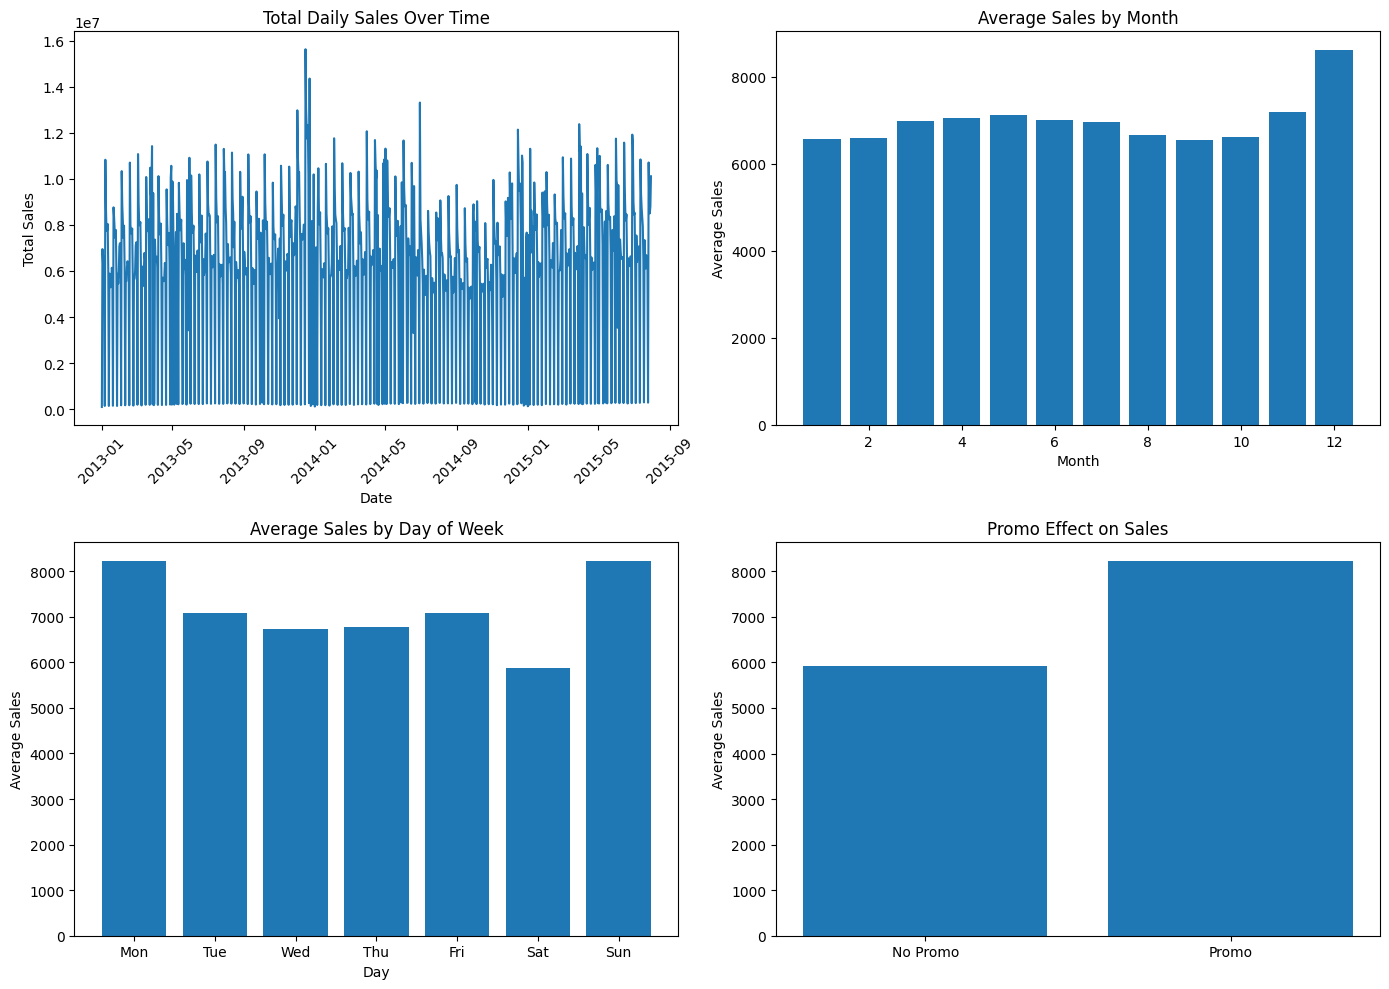

✓ Validation plots saved to images/data_cleaning_validation.png


In [14]:
# Cell 13: Quick visualization to verify cleaning
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sales over time
df_daily = df_final.groupby('Date')['Sales'].sum().reset_index()
axes[0, 0].plot(df_daily['Date'], df_daily['Sales'])
axes[0, 0].set_title('Total Daily Sales Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Sales')
axes[0, 0].tick_params(axis='x', rotation=45)

# Sales by month
monthly_sales = df_final.groupby('Month')['Sales'].mean()
axes[0, 1].bar(monthly_sales.index, monthly_sales.values)
axes[0, 1].set_title('Average Sales by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Sales')

# Sales by day of week
dow_sales = df_final.groupby('DayOfWeek')['Sales'].mean()
axes[1, 0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dow_sales.values)
axes[1, 0].set_title('Average Sales by Day of Week')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Average Sales')

# Promo effect
promo_effect = df_final.groupby('Promo')['Sales'].mean()
axes[1, 1].bar(['No Promo', 'Promo'], promo_effect.values)
axes[1, 1].set_title('Promo Effect on Sales')
axes[1, 1].set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../images/data_cleaning_validation.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Validation plots saved to images/data_cleaning_validation.png")